#### Zadanie: aproksymacja jednego cyklu EKG

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# okres
T = 1
t = np.linspace(0, T, 1000)

In [6]:
# "pseudo-EKG" – jeden okres
f = (
    1.2*np.exp(-((t-0.2)/0.03)**2)   # załamek P
    -2*np.exp(-((t-0.4)/0.01)**2)    # Q
    +5*np.exp(-((t-0.42)/0.008)**2)  # R
    -2*np.exp(-((t-0.44)/0.01)**2)   # S
    +1.5*np.exp(-((t-0.7)/0.05)**2)  # T
)

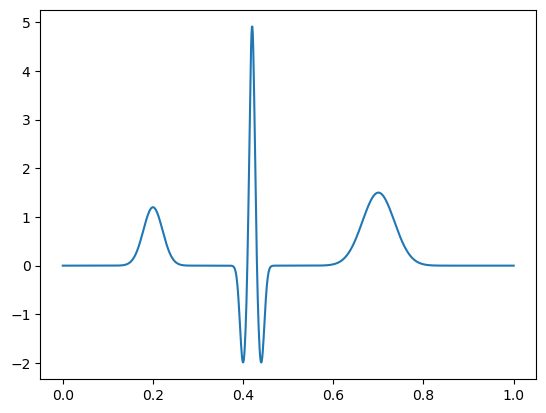

In [8]:
#wykres "pseudo-ekg"
plt.plot(t, f)

In [10]:
# --- współczynniki Fouriera ---
def compute_coeffs(f, t, T, N):
    a0 = (2/T) * np.trapz(f, t)
    an = []
    bn = []
    
    for n in range(1, N+1):
        an.append((2/T)*np.trapz(f*np.cos(2*np.pi*n*t/T), t))
        bn.append((2/T)*np.trapz(f*np.sin(2*np.pi*n*t/T), t))
    
    return a0, np.array(an), np.array(bn)

In [12]:
# --- rekonstrukcja ---
def reconstruct(t, T, a0, an, bn, N):
    s = a0/2
    for n in range(1, N+1):
        s += an[n-1]*np.cos(2*np.pi*n*t/T)
        s += bn[n-1]*np.sin(2*np.pi*n*t/T)
    return s

In [30]:
# liczba harmonicznych
N = 10

a0, an, bn = compute_coeffs(f, t, T, N)
f_rec = reconstruct(t, T, a0, an, bn, N)

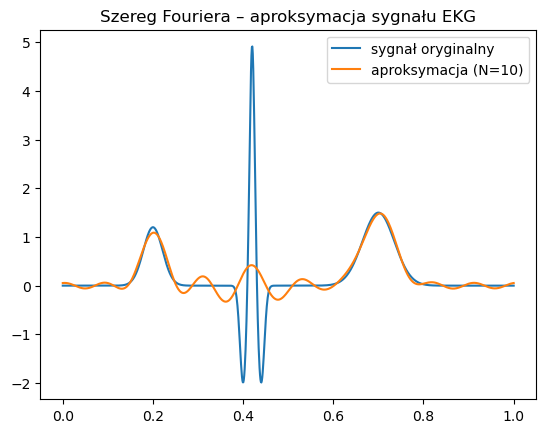

In [32]:
# --- wykres ---
plt.figure()
plt.plot(t, f, label="sygnał oryginalny")
plt.plot(t, f_rec, label=f"aproksymacja (N={N})")
plt.legend()
plt.title("Szereg Fouriera – aproksymacja sygnału EKG")
plt.show()